<a href="https://colab.research.google.com/github/Dan-nisimi/Machine-Learning-ADVANCE-SCRIPTS/blob/main/Advance_Machine_Learning_Algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#INTRODUCTION TO ENSEMBLE LEARNING

In [ ]:
#Ensemble learning is an ML technique that uses multiple models to make predictions and produce a final output that is more accurate than any of the individual models.

#Why does this improve performance?
# - It reduces variance by averaging the predictions of multiple models.
# - It reduces bias by combining the strengths of different models.
# - It can handle complex relationships between the features and the target variable.
# - It improves robustness to noise and outliers.

#Applications
# - Medical diagnosis
# - Fraud detection
# - Recommendation systems
# - Predictive analytics

#Types of ensemble learning
# - Bagging (Bootstrap Aggregating)
# This trains models independently on different subsets of the training data created using bootstrapping
#and then aggregates the predictions of the individual models by averaging them or majority voting(for classification) to produce a final prediction.
#Example is Random Forest. The strength is that it can handle high-dimensional data and is robust to noise and outliers. It can also reduce variance without increasing bias.

# - Boosting
# This uses a sequence of weak models to improve the accuracy of the final prediction. Each model is trained on the residuals of the previous model
#and focuses on correcting the errors of the previous model, which helps to reduce the bias of the model. Combines prediction through weighted averaging or voting.
#Examples are AdaBoost, XGBoost, LightGBM and Gradient Boosting. Strength is that it reduces bias and variance by focusing on hard to predict instances

# - Stacking
# This is a combination of bagging and boosting. It uses a meta-model to combine the predictions of multiple base models to produce a final prediction.
#Strength: It can utilize diverse model types to maximize performance

#Overview of common ensemble learning algorithms
# - Random Forest: Combines multiple decision trees and uses bagging to reduce variance and overfitting
# - Gradient Boosting: Sequences multiple weak models to reduce errors, bias and variance. Suitable for both classification and regression problems
# - Adaboost: Adjust models weight on misclassified instances to reduce bias
# - XGBoost:Optimized version of gradient boosting, known for speed and accuracy
#- VOting Classifier: Combines predictions of multiple models by majority voting

In [ ]:
#Ex: Build a basic ensemble model combining predictions from logistic regression, decision tree and K-NN to observe the impact on accuracy

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = load_iris()
X, y = data.data, data.target

# SPlit dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train individual models
log_model = LogisticRegression()
dt_model = DecisionTreeClassifier()
knn_model = KNeighborsClassifier()

log_model.fit(X_train, y_train) # Train model on training data and labels
dt_model.fit(X_train, y_train)# Train model on training data and labels
knn_model.fit(X_train, y_train)

# Creating Voting Classifier
ensemble_model = VotingClassifier(
    estimators=[
        ('log_reg', log_model),
        ('decision_tree', dt_model),
        ('knn', knn_model)
    ],
    voting='hard'
) #Hard voting is the default voting strategy in scikit-learn and it uses majority voting to combine the predictions of the individual models

# Train ensemble model
ensemble_model.fit(X_train, y_train)

# Predict with ensemble
y_pred_ensemble = ensemble_model.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred_ensemble)


# Evaluate individual models
y_pred_log = log_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_log):.2f}")
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt):.2f}")
print(f"k-NN Accuracy: {accuracy_score(y_test, y_pred_knn):.2f}")
print(f"Ensemble Model Accuracy: {accuracy:.2f}")

Logistic Regression Accuracy: 1.00
Decision Tree Accuracy: 1.00
k-NN Accuracy: 1.00
Ensemble Model Accuracy: 1.00


# BAGGING AND RANDOM FOREST

In [ ]:
#Bagging is a techniques that trains multiple models on different subsets of the data, created by random sampling with replacement.
#The models are then aggregated to produce a final prediction. This can be done by averaging the predictions (regression) of individual models,
#or by majority voting (classification) for the class with the highest count.

#Why use bagging
# - Reduces variance
# - Improves robustness

#Applications
#Bagging is commonly used with decision trees (which are prone to high variance) to reduce overfitting and improve generalization

#Random forest is a bagging technique where multiple decision trees are trained on different subsets of the data.
#Features are\;
#- Randomly selected from the available features, datapoints and splits
# - Bootstrapping is used to create different subsets of the data
# - Each tree is trained on a different subset of the data
# - The final prediction is obtained by averaging the predictions of the individual trees

#Advantages
# - Reduces overfitting
# - Improves accuracy
# - Handles high-dimensional data
# - handles both classification and regression problems effectively

#Key Parameters
# - Number of trees(n_estimators) is a hyperparameter that can be tuned to control the balance between bias and variance.
#large n_estimators can reduce variance but increase computational cost
#- max_depth is a hyperparameter that controls the maximum depth of each tree to prevent overfitting. Shallow trees generalize but may underfit
#- max_features is a hyperparameter that controls the number of features to consider when looking for the best split or splitting a node.
#options are "auto", "sqrt" and "log2"
#- min_samples_split is a hyperparameter that controls the minimum number of samples required to split a node.
#It prevents overly complex trees by ensuring that each node contains a minimum number of samples

In [ ]:
#Train a random forest classifier, tune its parameters and evaluate its performance

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

# Load Dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Display dataset informtaion
print("Features:", data.feature_names)
print("Classes: ", data.target_names)

# # Train Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy: ", accuracy)
print("\n Classification Report: \n", classification_report(y_test, y_pred))

# Define hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'max_features': ['sqrt', 'log2', 'None']
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

# Display best parameters and score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_}")

Features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Classes:  ['malignant' 'benign']
Random Forest Accuracy:  0.9649122807017544

 Classification Report: 
               precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
45 fits failed out of a total of 135.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
Best Cross-Validation Accuracy: 0.9626373626373625


# BOOSTING AND GRADIENT BOOSTING

In [ ]:
#Boosting is a technique that uses multiple weak models to improve the accuracy of a final model.
#Each model is trained on the residuals of the previous model to correct the errors of the previous model.

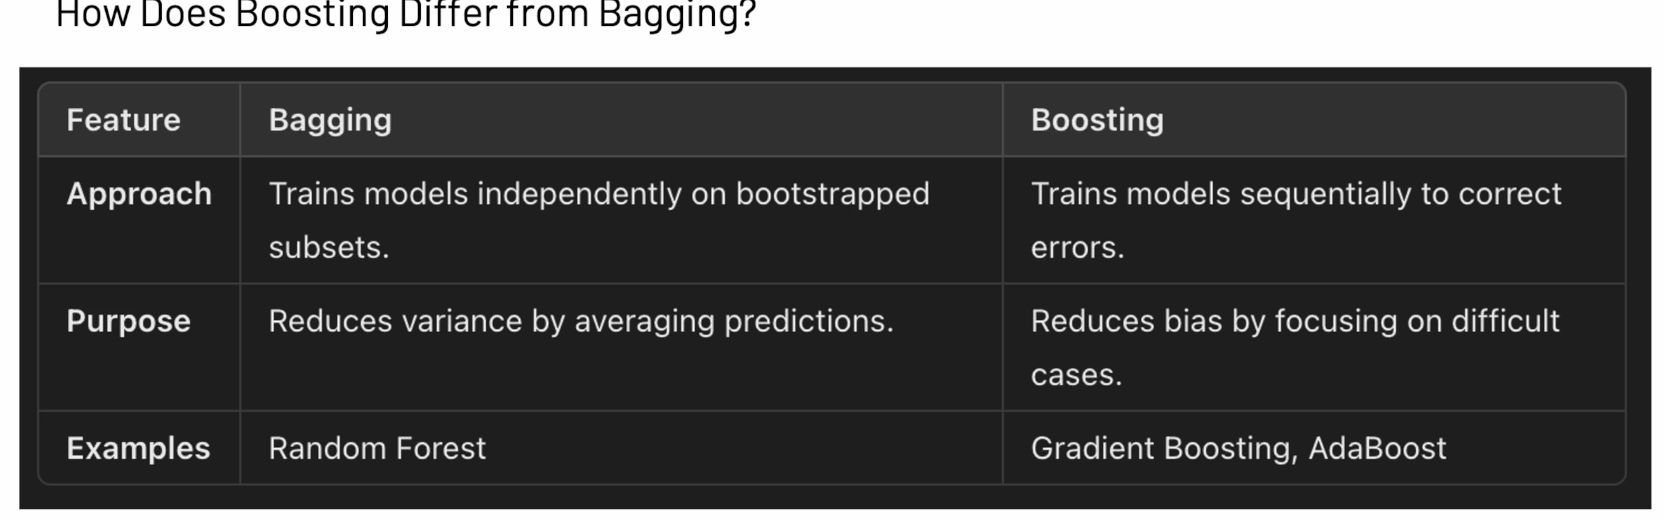

In [ ]:
#Gradient boosting is an algorithm that builds models sequentially by minimizing a loss function using a gradient-based optimization algorithm.
#It iteratively adds weak learners to improve overall model performance.

#How it works
# - Initialize a base model which often predict the mean of a target variable
# - Calculate the residuals of the base model i.e the difference between the actual and predicted values
# - Train a weak learner/model to predict the residuals e.g a shallow decision tree
# - Update the base model by adding the weak learner to it i.e adding the predictions of the weak learner to the overall model
# - Repeat steps 2-4 until a stopping criterion is met

#Key parameters in GBM
# - learning_rate is a hyperparameter that controls the step size of the gradient descent algorithm and determines the contribution of each weak learner
#smaller learning rate can reduce overfitting but requires more iterations, range is 0.01 to 0.3
# - n_estimators is a hyperparameter that controls the number of weak learners (trees) to added to the model or ensemble. Larger values improve learning
#BUT can increase computational costand risk overfitting
# - max_depth (regularization) is a hyperparameter that controls the maximum depth of each weak learner. It uses technique like limiting the tree depth
#or adding penalties to prevent overfitting. Limits individual tree complexity and shallow trees generalize better but may underfit

In [ ]:
#Exercise
#Train a gradient boosting model on a dataset, tune key parameters and compare its performance to a random forest model

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load Dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# display dataset information
print(f"Features: {data.feature_names}")
print(f"Classes: {data.target_names}")

# Train Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

# Predict
y_pred_gb = gb_model.predict(X_test)

# Evaluate performance
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"Gradient Boosting Accuracy: {accuracy_gb}")
print("\n Classification Report: \n", classification_report(y_test, y_pred_gb))

# Define hyperparameter grid
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7]
}

# Perform Grid Search for Gradient Boosting model
grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid, # hyperparameter grid to tune over
    cv=5, # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
#grid_search is used to find the best hyperparameters for the Gradient Boosting model

# Display best parametrs and score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_}")
#best cross validation accuracy means the accuracy of the model on the validation set
#is the highest it can get without overfitting the training data

# Train Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

## Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate Performance
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf}")


Features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Classes: ['malignant' 'benign']
Gradient Boosting Accuracy: 0.956140350877193

 Classification Report: 
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Bes

#INTRODUCTION TO XG-BOOST

In [ ]:
#XG-boost is an algorithm that uses a gradient-based optimization algorithm to train a tree-based model.
#It is a combination of gradient boosting and decision trees designed for speed and accuracy.
#It introduces various enhancements to boost performance, efficiency and speed. It is capable of handling
# large and complex datasets

#Improvements over XGBoost
# - Speed: It improves speed by using parallel processing and GPU acceleration
# - Handles large datasets
# - Handles complex relationships between features and target
# - Handles missing values: By learning from the data and imputing missing values
# - Regularization: By adding penalties such as L1 and L2 regularization terms to prevent overfitting
# - Custom loss functions: By allowing the user to specify their own loss functions
# - Tree punning: By pruning (means removing branches of the tree that are not important) trees to reduce overfitting

#Key features of XGBoost
# - Handling missing data: Automatically assignes missing values to the branch that minimizes the loss function
# and also reduces preprocessing steps for datasets with missing values
# - Regularization: By adding penalties such as L1(alpha) and L2(lambda) regularization terms for overly complex trees to prevent overfitting
#
# - Parallel processing: By using multiple cores to train models in parallel, calculations are speeded up and memory usage is reduced
#This improves training speed and accuracy
# - GPU acceleration: By using GPU to train models

#Hyperparamters in XG-Boost and How to Tune them
# - learning_rate (eta): Controls the contribution of each tree to the overall model.
#Typical range are 0.01 to 0.3.

# - n_estimators: Determines the number of trees to add to the model or the number of boosting rounds
#Typical range is 100 to 1000. Larger values improve learning but can increase computational cost

# - max_depth (regularization): Limits the depth of trees, balancing bias and variance. Shallow trees generalize better but may underfit
#while deeper trees may overfit

#-Subsample (regularization): This is a fraction of the training data that is used to train each tree. Reduces the influence of individual data points, balancing bias and variance
#Typical range is 0.5 to 1.0

#-Colsample_bytree (regularization): This is a fraction of the features that are used to train each tree. Reduces the influence of individual features, balancing bias and variance
#Typical range is 0.5 to 1.0

#-Regularization Parameters: L1 and L2 regularization are used to prevent overfitting by adding penalties to the loss function
#Typical range is 0.01 to 0.3

In [ ]:
pip install xgboost

In [ ]:
#Exercise
#Train an XGBoost model on a dataset, tune key parameters using cross-validation and compare its performance with  Gradient Boosting model

import xgboost as xgb
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Load Dataset
data = load_breast_cancer()
X, y = data.data, data.target

# SPlit dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display dataset info
print(f"Features: {data.feature_names}")
print(f"Classes: {data.target_names}")

# Convert dataset to DMatrix is used to pass data to XGBoost model
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Train XGBoost model
# Define hyperparameters
#objective is the loss function used for training the model, binary:logistic is used for binary classification
#eval_metric is the metric used for evaluating the model, logloss is used to evaluate the performance of the model
#max_depth is the maximum depth of the tree
#eta is the learning rate
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 3,
    'eta': 0.1
}


xgb_model = xgb.train(params, dtrain, num_boost_round=100)

# Predict
y_pred = (xgb_model.predict(dtest) > 0.5).astype(int)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"XGBoost Accuracy: {accuracy}")
print("\nClassification Report: \n", classification_report(y_test, y_pred))

# Define hyperparameter grid
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Initialize XGBoost classifier means create the model
xgb_clf = XGBClassifier(eval_metric='logloss', random_state=42)

# Perform Grid Search
#xgb_clf is the model we want to tune
#param_grid is the hyperparameter grid we want to tune over
#n_jobs is the number of jobs (CPU cores) to run in parallel
grid_search = GridSearchCV(estimator=xgb_clf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Display best parameters and score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_}")

# Train gradient boosting model
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

# Evaluate Gradient Boosting Performance
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"Gradient Boosting Accuracy: {accuracy_gb}")

Features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Classes: ['malignant' 'benign']
XGBoost Accuracy: 0.956140350877193

Classification Report: 
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Best Parameter

# LIGHT GBM AND CATBOOST

In [ ]:
#LightGBM is a gradient-based boosting algorithm that is designed to handle large datasets and high-demensional data
# with a focus on speed and accuracy

#Features of LightGBM
#- Histogram based splitting: It uses histogram-based splitting to find the best split point(threshold value for a feature value) for each feature
# - Leafwise Tree growth: It grows the tree in a leafwise manner, which means that the tree is built in a bottom-up manner, starting from the leaves and moving up to the root node
# - Support for GPU training: It supports GPU training, which can improve training speed and accuracy
# - Handling Sparse Data: LightGBM can handle sparse data, which is data where many features are missing or have a low frequency of occurrence

#Advantages of LightGBM
#- Fast training and inference than XGBoost: It is fast to train and inference on large datasets
#- Handles missing data: It can handle missing data, which is data where many features are missing or have a low frequency of occurrence
#- Handles large datasets effectively: It can handle large datasets efficiently amd reduces memory
#usage by using histogram-based splitting and leafwise tree growth

#When to use LightGBM
# - Large datasets with numerical features
# - Time sensitive tasks requireing fast training and inference


#CATBOOST is a library developed specifically to handle categorical features without the need for pre-processing like
#one hot encoding

#Key Features
# - Native Support for Categorical Features: Uses statistical encoding to handle categorical features preserving order and hierarchy
# - Ordered boosting: Reduces prediction bias by using a permutation-based approach to train the models robust to overfitting
# - Robust to overfitting: Implements built in regularization methods, and thats why it is robust to overfitting most times

#Advantages
# - Eliminates the need for manual encoding of categorical data or features
#- Reduces overfitting with robust boosting techniques

#When to use CatBoost
# - Large datasets with high proportion ofcategorical features
# - Applications where overfitting is a concern
# - Time sensitive tasks requiring fast training and inference


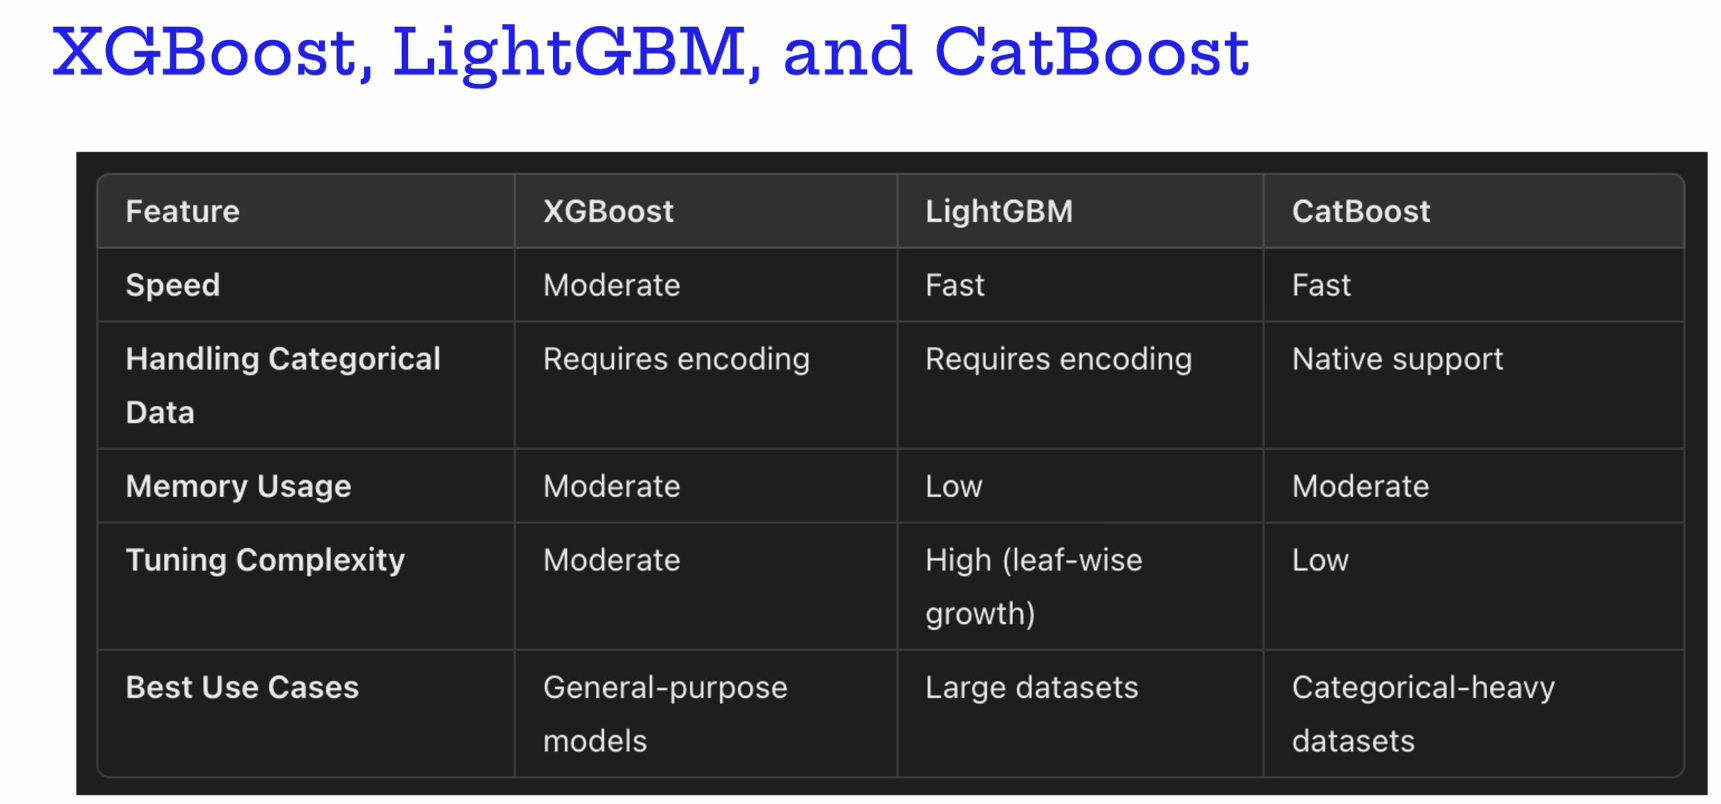

In [ ]:
pip install CatBoost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 4.1 MB/s eta 0:00:00


In [ ]:
#EX: Train and compare lightgbm, Catboost and XGBoost models on a dataset, focusing on their ability to handle large
#datasets and categorical features (data)


import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

# Load Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Select features and target
features = ['Pclass','Sex','Age','Fare', 'Embarked']
target = 'Survived'

# Handle missing values
df.fillna({'Age': df['Age'].median()}, inplace=True)
df.fillna({'Embarked': df['Embarked'].mode()[0]}, inplace=True)

# Encode categorical variables
label_encoders = {}
for col in ['Sex', 'Embarked']:
    le = LabelEncoder() # create a LabelEncoder object to encode(transform into a numerical value) the categorical variable
    df[col] = le.fit_transform(df[col])# fit the LabelEncoder object to the categorical variable
    label_encoders[col] = le # store the LabelEncoder object in a dictionary with the column name as the key

# SPlit Data
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Traing Data Shape: {X_train.shape}")
print(f"Test Data Shape: {X_test.shape}")

#shape means number of rows and columns

# Train LightGBM model
lgb_model = lgb.LGBMClassifier()
lgb_model.fit(X_train, y_train)

# Predict and evaluate
lgb_pred = lgb_model.predict(X_test)
#.4f means 4 decimal places
print(f"LightGBM Accuracy: {accuracy_score(y_test, lgb_pred):.4f}")

# Train CatBoost model
#cat_features is a list of categorical features to be used in the model
cat_features = ['Pclass', 'Sex', 'Embarked']
#verbose=0 means no output from the model
#cat_model is the model we want to train
#catboostclassifier is the class we want to use to train the model
cat_model = CatBoostClassifier(cat_features=cat_features, verbose=0)
cat_model.fit(X_train, y_train)

# Predict and evaluate
cat_pred = cat_model.predict(X_test)
print(f"CatBoost Accuracy: {accuracy_score(y_test, cat_pred):.4f}")

# Train XGBoost model
xgb_model = XGBClassifier(eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predict and evaluate
xgb_pred = xgb_model.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")


# Train Catboost without encoding categorical features
#this means that the model will not use any encoding(like one hot encoding which
# means that the model will create a new column for each categorical value) for the categorical features
cat_model_native = CatBoostClassifier(cat_features=['Sex', 'Embarked'], verbose=0)
cat_model_native.fit(X_train, y_train)

# Predict and evaluate
cat_preds_native = cat_model_native.predict(X_test)
print(f"CatBoost Native Accuracy: {accuracy_score(y_test, cat_preds_native):.4f}")


Traing Data Shape: (712, 5)
Test Data Shape: (179, 5)
[LightGBM] [Info] Number of positive: 268, number of negative: 444
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 180
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM]

# HANDLING IMBALANCED DATA

In [ ]:
#Problems caused by Imbalanced data in Classification Tasks

#Imbalanced data refers to datasets where the distribution of the classes is not even, meaning that one class has a much higher
#number of instances than the other classes

#Challenges includes:
#- High bias: The model is biased towards the majority class, which can lead to poor performance on the minority class
#- High variance: The model is sensitive to small changes in the data, which can lead to overfitting
# - Misleading evaluation metrics: The evaluation metrics used to measure the performance of the model may not be appropriate for imbalanced data or might
#not account for the class imbalance
# - Limited information for minority classes: The model may not have enough samples to make accurate predictions for the minority class and this
#can lead to underfitting
# - Applications with Imbalanced data e.g Fraud detection, medical diagnosis, anomaly detection (Imabalanced data in any of this will cause problems)

#Techniques to handle imbalanced data:
# - Oversampling: Adding more instances of the minority class to the dataset by duplicating or synthesizing them to balance the class distribution
#e.g using SMOTE (Synthetic Minority Over-sampling Technique) which generate synthetic examples or ADASYN (Adaptive Synthetic)

#- Undersampling: Reduce the number of majority class samples to balance the class distribution. The risk is loss of valuable information for the majority class

# - Algorithmic solutions: Using algorithms that are designed to handle imbalanced data, e.g using class weights
#a. Class weights can be used to assign different or higher weights to the classes during model
#training to give more importance to the minority class. Algorithms like logistic regression and RF have support fir class weights.
#b. Anomaly detection models; Treat the class like anomalies and use anomaly detection algorithms or the models to detect them

#Evaluation Metrics for Imabalanced data

#f1-score: a combination of precision and recall that is useful when the classes are imbalanced by focusing on both false positives and false negatives
#ROC-AUC : Measures the ability to distinguish between classes across various threshold values
#Precision-Recall curve: Focuses on the performance for the +ve class

In [ ]:
#Exercise: Apply SMOTE to handle class imbalance, train a classifier and evaluate its performance using metrics like ROC_AUC and f1-score

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE

# Load dataset
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)

# Explore dataset
print("Dataset Info:\n")
print(df.info())
print("\n Class Distribution:\n")
print(df["Class"].value_counts()) #.value_counts returns the count of each unique value in the column

# SPlit dataset
X = df.drop(columns=['Class'])
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
#class_weight="balanced" means that the model will give more importance to the minority class
rf_model = RandomForestClassifier(random_state=42, class_weight="balanced")
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = rf_model.predict(X_test)
print("\n CLassification Report:\n")
print(classification_report(y_test, y_pred))

#[:,1] means that we want the second column which is the probability of the positive class
roc_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])
print(f"ROC-AUC: {roc_auc:.2f}")

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Display new class distribution
print("\n Class Distribution After SMOTE: \n")
print(pd.Series(y_resampled).value_counts())

# Train Random Forest on resampled data
rf_model_smote = RandomForestClassifier(random_state=42)
rf_model_smote.fit(X_resampled, y_resampled)

# Predict and evaluate
y_pred_smote = rf_model_smote.predict(X_test)
print("\n CLassification Report (SMOTE):\n")
print(classification_report(y_test, y_pred_smote))

roc_auc_smote = roc_auc_score(y_test, rf_model_smote.predict_proba(X_test)[:,1])
print(f"ROC-AUC (SMOTE): {roc_auc_smote:.2f}")

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64


# ENSEMBLE LEARNING PROJECT: COMPARING MODELS ON REAL DATASET

In [ ]:
#Why compare ensemble models?

#Ensemble models are models that combine the predictions of multiple individual models to make a final prediction.
#They excel in different scenarios and they help identify the most effective model for a given task or dataset

#Ensemble methods to consider are bagging (e.g RF), boosting (e.g XGBoost, LightGBM & gradient boosting)

#Comparing Bagging and Boosting
#Bagging builds model independently using random subsets of data. It is also robust against overfitting with strong base learners
#Boosting builds models sequentially, focusing on hard-to-predict samples. requires careful tunning to prevent overfitting

In [5]:
#Create an upload button
from google.colab import files
uploaded = files.upload()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn (1).csv


In [7]:
print(df.columns)

Index(['customer_id', 'gender', 'age', 'tenure', 'monthly_charges',
       'total_charges', 'contract_type', 'payment_method', 'churn'],
      dtype='object')


In [19]:
#Hands on Project: Ensemble learning and Model Comparison
#Objectives: Train and compare multiple ensemble models on real-world dataset, analyzing their performance under balanced and imbalanced conditions

import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score



# Load Dataset
df = pd.read_csv("Telco-Customer-Churn.csv")

print(df.head())


# Display dataset info and preview
print("Dataset Info: \n")
print(df.info())
print("\n Class Distribution: \n")
print(df['churn'].value_counts())
print("\n Sample Data:\n", df.head())

# Handle missing values
#inplace=True means that we want to modify the original dataframe instead of creating a new one
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')
df.fillna({'total_charges': df['total_charges'].median()}, inplace=True)

# Encode categorical variables
label_encoder = LabelEncoder()
#include=['object'] means that we want to encode only categorical variables
for column in df.select_dtypes(include=['object']).columns:
    if column != 'churn':
        df[column] = label_encoder.fit_transform(df[column]) # fit_transform means that we want to fit the encoder to the data

# Encode target variable
df['churn'] = label_encoder.fit_transform(df['churn'])

# Scale numerical features
scaler = StandardScaler()
numerical_features = ['tenure', 'monthly_charges', 'total_charges']
df[numerical_features] = scaler.fit_transform(df[numerical_features])

# Features and Target
X = df.drop(columns=['churn'])
y = df['churn']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Display class distribution after SMOTE
print("\n Class Distribution after SMOTE: \n")
print(pd.Series(y_train_resampled).value_counts())

# Train Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf_model.predict(X_test)
roc_auc_rf = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])

# Train XGBoost
xgb_model = XGBClassifier(eval_metric='logloss',random_state=42)
xgb_model.fit(X_train_resampled, y_train_resampled)
y_pred_xgb = xgb_model.predict(X_test)
roc_auc_xgb = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])

# Train LightGBM
lgb_model = LGBMClassifier(random_state=42)
lgb_model.fit(X_train_resampled, y_train_resampled)
y_pred_lgb = lgb_model.predict(X_test)
roc_auc_lgb = roc_auc_score(y_test, lgb_model.predict_proba(X_test)[:, 1])

# Classification reports
print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))
print("XGBoost Report: \n", classification_report(y_test, y_pred_xgb))
print("LightGBM Report: \n", classification_report(y_test, y_pred_lgb))

# ROC_AUC comparison
print("ROC-AUC Scores: \n")
print(f"Random Forest: {roc_auc_rf:.2f}")
print(f"XGBoost: {roc_auc_xgb:.2f}")
print(f"LightGBM: {roc_auc_lgb:.2f}")


   customer_id  gender  age  tenure  monthly_charges  total_charges  \
0            1    Male   38       1            32.96      35.280731   
1            2  Female   49      51            87.32    4821.395573   
2            3    Male   40      45            87.71    4120.627510   
3            4    Male   50       4            96.42     356.816850   
4            5    Male   20      62            32.37    1823.181566   

  contract_type payment_method  churn  
0      Two-Year   Mailed Check      1  
1        Annual   Mailed Check      0  
2      Two-Year   Mailed Check      1  
3        Annual    Credit Card      0  
4        Annual    Credit Card      0  
Dataset Info: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      500 non-null    int64  
 1   gender           500 non-null    object 
 2   age              500 non